<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/project_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 20 - Iris clustering

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("Iris.csv")

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [ ]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [ ]:
X = df.iloc[:,1:6]

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

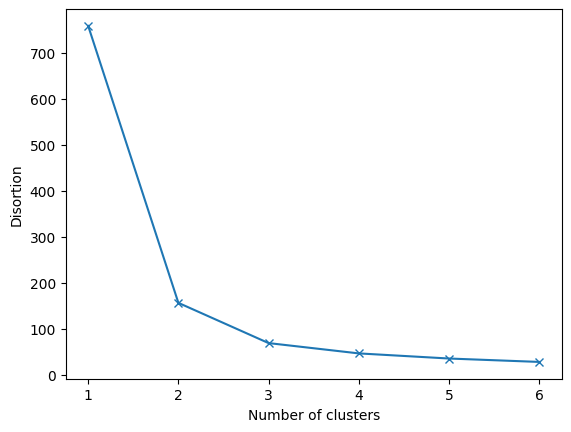

In [ ]:
disortion = []
for i in range(1,7):
  model = KMeans(n_clusters=i,random_state=42,init='k-means++',n_init=10)
  model.fit(X_pca)
  disortion.append(model.inertia_)
plt.plot(range(1,7),disortion,marker='x')
plt.xlabel('Number of clusters')
plt.ylabel('Disortion')
plt.show()

In [ ]:
model = KMeans(n_clusters=3,random_state=42,init='k-means++',n_init=10)

In [ ]:
model.fit(X_pca)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
y=model.predict(X_pca)

<function matplotlib.pyplot.show(close=None, block=None)>

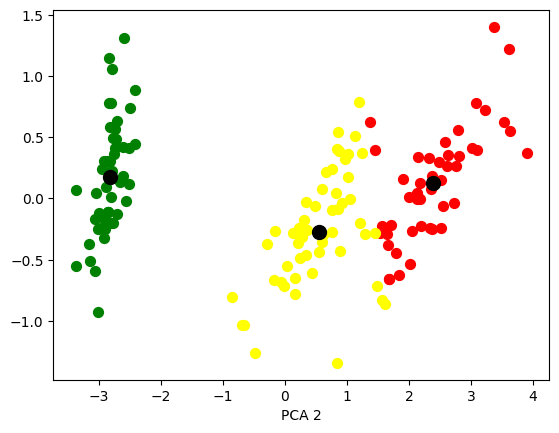

In [ ]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='green',label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='yellow',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.xlabel("PCA 1")
plt.xlabel("PCA 2")
plt.show